# 1. Setup and Load Data

### 1.1 install dependencies

In [1]:
!pip install tensorflow opencv-python matplotlib

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.0-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip list

Package                 Version
----------------------- -----------
absl-py                 2.3.1
asttokens               3.0.0
astunparse              1.6.3
certifi                 2025.10.5
charset-normalizer      3.4.4
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
flatbuffers             25.9.23
fonttools               4.60.1
gast                    0.6.0
google-pasta            0.2.0
grpcio                  1.76.0
h5py                    3.15.1
idna                    3.11
ipykernel               7.0.1
ipython                 9.6.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.6.3
jupyter_core            5.9.1
keras                   3.11.3
kiwisolver              1.4.9
libclang                18.1.1
Markdown                3.9
markdown-it-py          4.0.0
MarkupSafe           

In [4]:
import tensorflow as tf
import os

In [8]:
# avoid oom errors by setting GPU memory consumption growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gup in gpus:
    tf.config.experimental.set_memroy_growth(gpu, True)

### 1.2 Remove some images

In [13]:
import cv2 as cv

In [10]:
data_dir = 'data'

In [14]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [15]:
os.listdir(os.path.join('data','happy'))

['0-truly-happy-people.jpg',
 '05-12-21-happy-people.jpg',
 '163-1635185_happy-people-cartoon-png-transparent-png.png',
 '227-2271651_picture-of-a-group-of-happy-people-hugging.png',
 '29-291730_happy-people-image-happy-people-transparent-backgr.png',
 '291-2916674_com-all-rights-reserved-happy-people-png.png',
 '297-2975290_happy-people-cartoon-png-transparent-png.png',
 '2983960_stock-photo-happy-people.jpg',
 '31b30073bf691224a4814d0495a2fee712daad529d73326f095cf0d22fdd.png',
 '323-3239647_happy-people-png-transparent-png.png',
 '35438_hd.jpg',
 '360_F_484873483_hg1ofIdXbMha5lKEDG3hJBrwKh1oikTq.jpg',
 '364-3644960_happy-people-png-for-kids-happy-man-transparent.png',
 '4-things-happy-people-dont-do-cover.png',
 '4239f3d51d092f69d529f372a37b4601.jpg',
 '427394C200000578-4707164-Happy_people_are_healthier_Some_65_.jpg',
 '677-6778699_transparent-people-jumping-png-happy-people-cart.png',
 '7-principles-of-successful-and-happy-people.png',
 '867a9736361d5928c584b8c605d5ca0a.jpg',
 '8cx

In [16]:
for image_class in os.listdir(data_dir):
    print(image_class)

happy
sad


In [18]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)
    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        try:
            img = cv.imread(image_path)
            # If cv2.imread() fails, it returns None
            if img is None:
                print(f"Invalid image: {image_path}")
                os.remove(image_path)
                continue

            # Check the file extension manually
            ext = image.split('.')[-1].lower()
            if ext not in image_exts:
                print(f"Image not in extension list: {image_path}")
                os.remove(image_path)

        except Exception as e:
            print(f"Issue with image {image_path}: {e}")
            # os.remove(image_path)


### 1.3 Load Data

In [20]:
tf.data.Dataset??

Init signature: tf.data.Dataset(variant_tensor)
Source:        
@tf_export("data.Dataset", v1=[])
class DatasetV2(
    collections_abc.Iterable,
    tracking_base.Trackable,
    composite_tensor.CompositeTensor,
    data_types.DatasetV2,
    metaclass=abc.ABCMeta):
  """Represents a potentially large set of elements.

  The `tf.data.Dataset` API supports writing descriptive and efficient input
  pipelines. `Dataset` usage follows a common pattern:

  1. Create a source dataset from your input data.
  2. Apply dataset transformations to preprocess the data.
  3. Iterate over the dataset and process the elements.

  Iteration happens in a streaming fashion, so the full dataset does not need to
  fit into memory.

  Source Datasets:

  The simplest way to create a dataset is to create it from a python `list`:

  >>> dataset = tf.data.Dataset.from_tensor_slices([1, 2, 3])
  >>> for element in dataset:
  ...   print(element)
  tf.Tensor(1, shape=(), dtype=int32)
  tf.Tensor(2, shape=(), dty

In [21]:
import numpy as np
from matplotlib import pyplot as plt

In [23]:
tf.keras.utils.image_dataset_from_directory??
# this shows the documentation

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)
Source:   
@keras_export(
    [
        "keras.utils.image_dataset_from_directory",
        "keras.preprocessing.image_dataset_from_directory",
    ]
)
def image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    ve

In [22]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 180 files belonging to 2 classes.


In [44]:
type(data)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [25]:
data_iterator = data.as_numpy_iterator()

In [39]:
batch = data_iterator.next()

In [34]:
# 2 parts of the data (images and labels)
len(batch)

2

In [35]:
# images represented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [42]:
# Labels represented as numpy array
# class 1 : sad
# class 0 : happy
batch[1]

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0], dtype=int32)

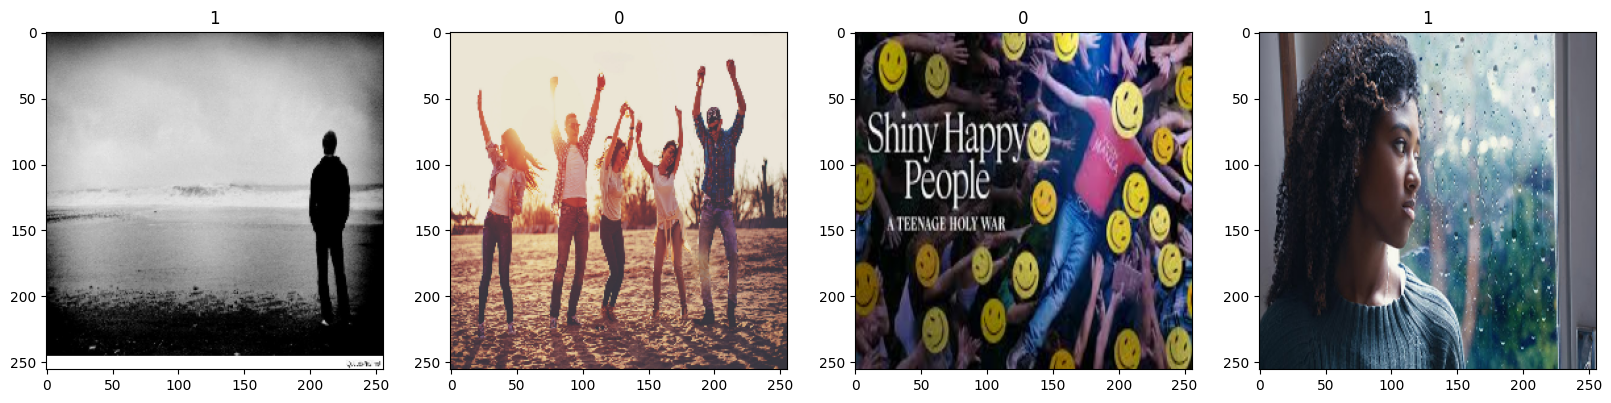

In [43]:
#plot the images

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])  

# 2.0 Data Preprocessing

### 2.1 Data scaling

In [51]:
#0 - 255
scaled = batch[0]/255

In [58]:
scaled.min()

np.float32(0.0)

In [53]:
data = data.map(lambda x,y: (x/255, y))

In [75]:
data.as_numpy_iterator().next()[0]

array([[[[0.75686276, 0.7490196 , 0.69803923],
         [0.77254903, 0.7647059 , 0.7137255 ],
         [0.7759804 , 0.7681373 , 0.7171569 ],
         ...,
         [0.6666667 , 0.65882355, 0.60784316],
         [0.6666667 , 0.65882355, 0.60784316],
         [0.6666667 , 0.65882355, 0.60784316]],

        [[0.75686276, 0.7490196 , 0.69803923],
         [0.77254903, 0.7647059 , 0.7137255 ],
         [0.7759804 , 0.7681373 , 0.7171569 ],
         ...,
         [0.6666667 , 0.65882355, 0.60784316],
         [0.6666667 , 0.65882355, 0.60784316],
         [0.6666667 , 0.65882355, 0.60784316]],

        [[0.75686276, 0.7490196 , 0.69803923],
         [0.77254903, 0.7647059 , 0.7137255 ],
         [0.7759804 , 0.7681373 , 0.7171569 ],
         ...,
         [0.67058825, 0.6627451 , 0.6117647 ],
         [0.6666667 , 0.65882355, 0.60784316],
         [0.6666667 , 0.65882355, 0.60784316]],

        ...,

        [[0.6716912 , 0.66384804, 0.61286765],
         [0.68541664, 0.6775735 , 0.6265931 ]

### 2.2 Data splitting

In [59]:
len(data)

6

In [60]:
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)
test_size = int(len(data)*0.2)

In [67]:
train_size + val_size + test_size

6

In [68]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [71]:
len(val)

1

# 3.0 Model Building

### 3.1 Build Deep CNN

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [88]:
model = Sequential()

In [89]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [91]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [92]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Training the model

In [94]:
logdir='logs'

In [95]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [97]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 420ms/step - accuracy: 0.5312 - loss: 0.7873 - val_accuracy: 0.5625 - val_loss: 0.6920
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 0.5078 - loss: 0.6638 - val_accuracy: 0.7188 - val_loss: 0.5685
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.6250 - loss: 0.5714 - val_accuracy: 0.8750 - val_loss: 0.4993
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 0.8516 - loss: 0.5116 - val_accuracy: 0.7500 - val_loss: 0.4293
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.7656 - loss: 0.4993 - val_accuracy: 0.8438 - val_loss: 0.3494
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.8672 - loss: 0.3686 - val_accuracy: 0.7188 - val_loss: 0.5714
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 0.8438 - loss: 0.3380 - val_accuracy: 1.0000 - val_loss: 0.2022
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 359ms/step - accuracy: 0.8906 - loss: 0.2722 - val_accuracy: 0.9688 - val_loss:

### 3.3 plot performance

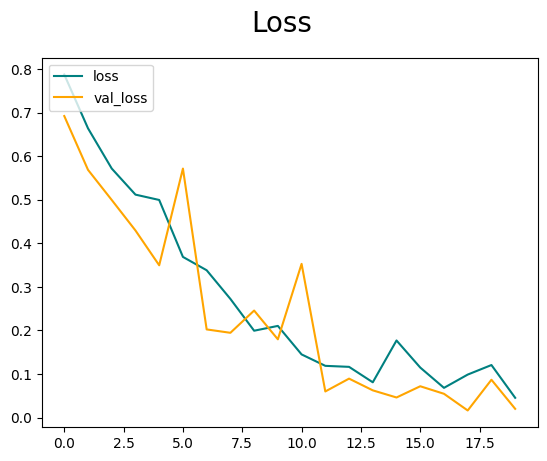

In [99]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

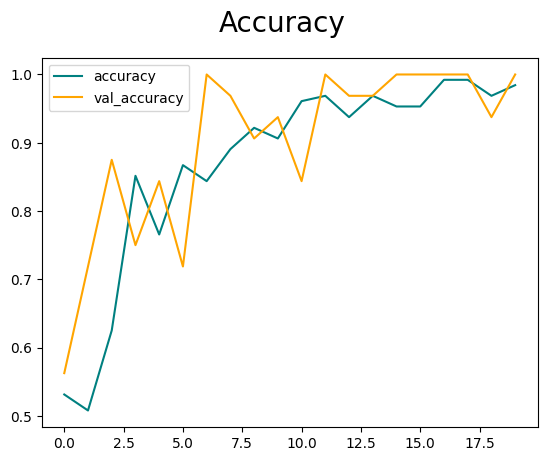

In [100]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc='upper left')
plt.show()

# 4.0 Performance Evaluation

### 4.1 Evaluate

In [101]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [102]:
precision = Precision()
recall = Recall()
accuracy = BinaryAccuracy()

In [105]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    precision.update_state(y, yhat)
    recall.update_state(y, yhat)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [109]:
print(f'Precision : {precision.result().numpy()}, Recall : {recall.result().numpy()},Accuracy : {accuracy.result().numpy()}')

Precision : 1.0, Recall : 1.0,Accuracy : 1.0


### 4.2 Test

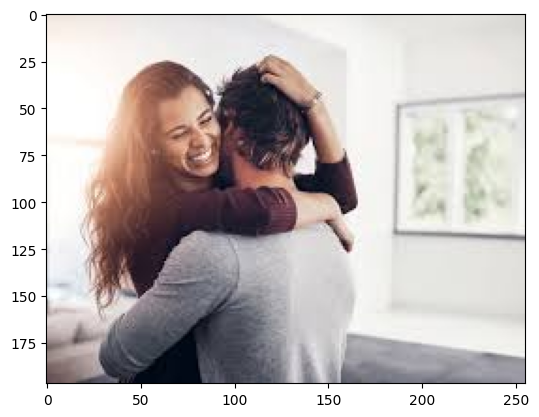

In [131]:
img = cv.imread('happytest2.jpeg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

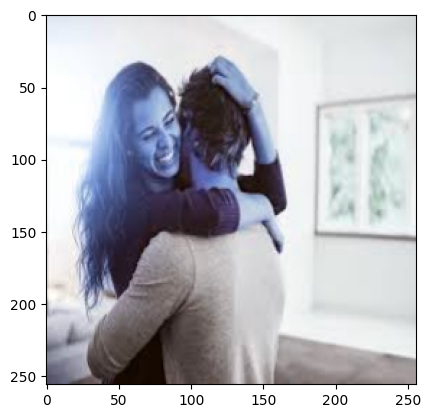

In [132]:
resized = tf.image.resize(img, (256,256))
plt.imshow(resized.numpy().astype(int))
plt.show()

In [133]:
yhat = model.predict(np.expand_dims(resized/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [134]:
yhat

array([[0.48252165]], dtype=float32)

In [135]:
if yhat > 0.5:
    print("sad")
else:
    print("happy")

happy


# 5.0 Save the model

In [136]:
from tensorflow.keras.models import load_model

In [144]:
model.save(os.path.join('models', 'emotionmodel.h5'))

In [145]:
new_model = load_model(os.path.join('models', 'emotionmodel.h5'))

In [146]:
yhat_new = new_model.predict(np.expand_dims(resized/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


In [147]:
if yhat_new > 0.5:
    print("sad")
else:
    print("happy")

happy
